## Dependencias

In [37]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error


from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Lambda
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_columns', 200)

## Lectura de Datos

In [2]:
df_lstm = pd.read_parquet(r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\DataCleaned\df_full.parquet")

df_lstm.head()

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,master_id,sell_price,master_id_1
0,HOBBIES_1_169_WI_3_validation,HOBBIES_1_169,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_169_WI_3_11523,0.5700,HOBBIES_1_169_WI_3_11523
1,HOBBIES_1_171_WI_3_validation,HOBBIES_1_171,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_171_WI_3_11523,2.8800,HOBBIES_1_171_WI_3_11523
2,HOBBIES_1_172_WI_3_validation,HOBBIES_1_172,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_172_WI_3_11523,2.9800,HOBBIES_1_172_WI_3_11523
3,HOBBIES_1_173_WI_3_validation,HOBBIES_1_173,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,2,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_173_WI_3_11523,10.9700,HOBBIES_1_173_WI_3_11523
4,HOBBIES_1_174_WI_3_validation,HOBBIES_1_174,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_174_WI_3_11523,4.8800,HOBBIES_1_174_WI_3_11523


In [3]:
df_lstm = df_lstm.sort_values(["id", "date"]).reset_index(drop=True).copy()

df_lstm = df_lstm[['id',
          'item_id',
          'dept_id',
          'cat_id',
          'store_id',
          'state_id',
          'date',
          'wm_yr_wk',
          'wday',
          'month',
          'year',
          'event_type_1',
          'snap_CA',
          'snap_TX',
          'snap_WI',
          'sales',
          'sell_price']].copy()

## Feature Engineering

In [4]:
aux = (df_lstm.isna().sum() / df_lstm.shape[0]).reset_index(name='nans')
aux = aux.sort_values('nans', ascending=False).reset_index(drop=True)

aux

,index,nans
0,event_type_1,0.9231
1,sell_price,0.0189
2,id,0.0000
3,item_id,0.0000
4,dept_id,0.0000
5,state_id,0.0000
6,date,0.0000
7,cat_id,0.0000
8,store_id,0.0000
9,wday,0.0000


In [5]:
# Colisionamos las variables snap

df_lstm['snap_active'] = 0

df_lstm.loc[df_lstm['state_id'] == 'CA', 'snap_active'] = df_lstm['snap_CA']
df_lstm.loc[df_lstm['state_id'] == 'TX', 'snap_active'] = df_lstm['snap_TX']
df_lstm.loc[df_lstm['state_id'] == 'WI', 'snap_active'] = df_lstm['snap_WI']

df_lstm.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'], inplace=True)

In [6]:
df_lstm.dropna(subset=['sell_price'], inplace=True)

In [7]:
group = df_lstm.groupby('id')

In [8]:
# Precios

df_lstm['price_lag_28'] = group['sell_price'].shift(28)

df_lstm['price_chg_28'] = group['sell_price'].pct_change(28)

In [9]:
df_lstm['event_type_1'] = df_lstm['event_type_1'].fillna('None')
df_lstm['event_type_1'].value_counts()

event_type_1
None         18663010
National       568259
Religious      538736
Cultural       331628
Sporting       120980
Name: count, dtype: int64

In [10]:
df_lstm['is_event'] = (df_lstm['event_type_1']!='None').astype(int)

df_lstm['snap_event'] = df_lstm['snap_active'] * df_lstm['is_event']

In [11]:
# Eliminamos wm_yr_wk porque tiene índice de tiempo implícito
df_lstm.drop(columns=['wm_yr_wk'], inplace=True)

df_lstm['wday_sin'] = np.sin(2 * np.pi*df_lstm['wday']/7)
df_lstm['wday_cos'] = np.cos(2*np.pi*df_lstm['wday']/7)

df_lstm['month_sin'] = np.sin(2 * np.pi*df_lstm['month']/12)
df_lstm['month_cos'] = np.cos(2*np.pi*df_lstm['month']/12)

df_lstm['week'] = pd.to_datetime(df_lstm['date']).dt.isocalendar().week.astype(int)

df_lstm["week_sin"] = np.sin(2 * np.pi * df_lstm["week"] / 52)
df_lstm["week_cos"] = np.cos(2 * np.pi * df_lstm["week"] / 52)


## Feature Engineering con clusterización

In [12]:
agg = df_lstm.groupby('id')['sales'].agg([
    'mean','std','max','min'
])

### Método del codo

Text(0, 0.5, 'Inertia')

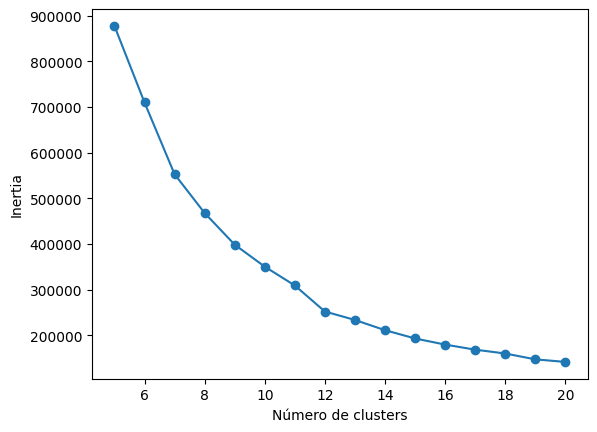

In [13]:
inertia = []

rango_ = range(5,21)

for k in rango_:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(agg)
    inertia.append(kmeans.inertia_)
    
plt.plot(rango_, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')

Siguiendo la gráfica del codo, la inercia cambia en el cluster 12.

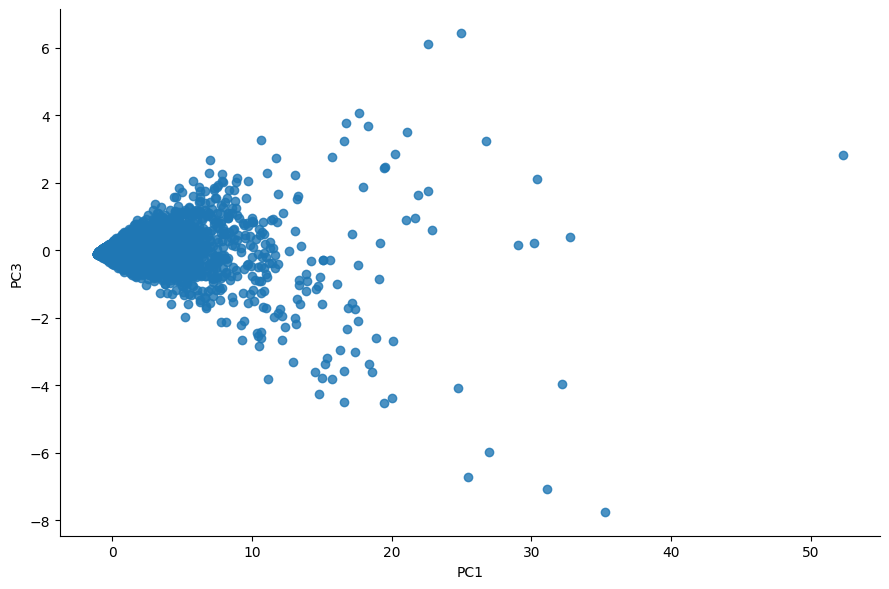

In [14]:
sc = StandardScaler()

agg_scaled = sc.fit_transform(agg)
pca = PCA(n_components=3, random_state=42)

agg_pca = pca.fit_transform(agg_scaled)
agg_pca_df = pd.DataFrame(agg_pca, columns=['PC1', 'PC2', 'PC3'])

sns.lmplot(
    x='PC1', 
    y='PC3', 
    data=agg_pca_df, 
    height=6, 
    aspect=1.5, 
    fit_reg=False
)

In [15]:
kmeans = KMeans(n_clusters=10, random_state=42)

agg['cluster'] = kmeans.fit_predict(agg_scaled)

In [16]:
agg[['cluster']].reset_index(drop=True).shape, agg_pca_df.shape

((30490, 1), (30490, 3))

In [17]:
agg_pca_df = pd.concat([agg_pca_df, agg[['cluster']].reset_index(drop=True)], axis=1)

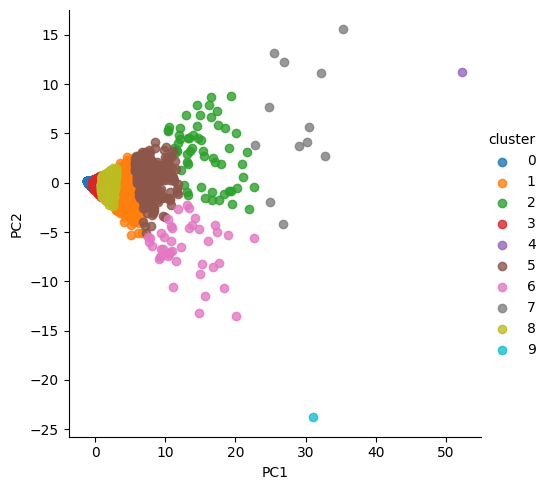

In [18]:
sns.lmplot(
    data=agg_pca_df,
    x='PC1',
    y='PC2',
    fit_reg=False,
    hue='cluster',
)

In [19]:
df_lstm = df_lstm.merge(agg[['cluster']], left_on='id', right_index=True, how='left')

df_lstm['cluster'].value_counts()

cluster
0    12912432
3     5031248
8     1462114
1      568976
5      170779
2       39208
6       28392
7        8112
4         676
9         676
Name: count, dtype: int64

In [20]:
def tablaDesc(cluster,df,variable):
    tabla = (
        df.groupby(cluster, as_index=False)
        .agg({
            variable: [
                'count',
                'mean',
                'std',
                'min',
                ('p25', lambda x: np.percentile(x, 25)),
                ('p50', lambda x: np.percentile(x, 50)),  # <- mediana explícita
                ('p75', lambda x: np.percentile(x, 75)),
                'max',
            ]
            })
    )

    tabla.columns = [
    f"{var}_{stat}" if stat else var
    for var, stat in tabla.columns
    ]
    
    return tabla

In [21]:
perf_table = tablaDesc('cluster', df_lstm, 'sales')

perf_table

,cluster,sales_count,sales_mean,sales_std,sales_min,sales_p25,sales_p50,sales_p75,sales_max
0,0,12912432,0.3807,0.7799,0,0.0000,0.0000,1.0000,15
1,1,568976,6.6386,6.8190,0,1.0000,5.0000,10.0000,128
2,2,39208,31.2137,20.8978,0,18.0000,30.0000,43.0000,213
3,3,5031248,1.4431,1.8524,0,0.0000,1.0000,2.0000,36
4,4,676,100.1257,64.3696,0,65.0000,104.0000,140.0000,323
5,5,170779,13.7261,11.8077,0,4.0000,12.0000,20.0000,130
6,6,28392,9.2669,16.1165,0,0.0000,3.0000,13.0000,349
7,7,8112,57.9157,36.8721,0,37.0000,59.0000,80.0000,260
8,8,1462114,3.5847,3.7909,0,0.0000,3.0000,5.0000,61
9,9,676,8.3772,28.5749,0,3.0000,5.0000,9.0000,567


In [22]:
df_lstm.head()

,id,item_id,dept_id,cat_id,store_id,state_id,date,wday,month,year,event_type_1,sales,sell_price,snap_active,price_lag_28,price_chg_28,is_event,snap_event,wday_sin,wday_cos,month_sin,month_cos,week,week_sin,week_cos,cluster
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-06-19,6,6,2014,None,0,2.2400,0,NaN,NaN,0,0,-0.7818,0.6235,0.0000,-1.0000,25,0.1205,-0.9927,0
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-06-20,7,6,2014,None,1,2.2400,0,NaN,NaN,0,0,-0.0000,1.0000,0.0000,-1.0000,25,0.1205,-0.9927,0
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-06-21,1,6,2014,None,0,2.2400,0,NaN,NaN,0,0,0.7818,0.6235,0.0000,-1.0000,25,0.1205,-0.9927,0
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-06-22,2,6,2014,None,1,2.2400,0,NaN,NaN,0,0,0.9749,-0.2225,0.0000,-1.0000,25,0.1205,-0.9927,0
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2014-06-23,3,6,2014,None,2,2.2400,0,NaN,NaN,0,0,0.4339,-0.9010,0.0000,-1.0000,26,-0.0000,-1.0000,0


## Selección de variables

In [23]:
# Variables Continuas

varc = ['sales', 'sell_price',
       'snap_active', 'price_lag_28', 'price_chg_28', 'snap_event',
       'wday_sin', 'wday_cos', 'month_sin', 'month_cos', 'week', 'week_sin',
       'week_cos']

# Variables Categóricas

vard = [
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id',
    'cluster'
]

In [24]:
encoders = {}

for col in vard:
    le = LabelEncoder()
    df_lstm[col] = le.fit_transform(df_lstm[col])
    encoders[col] = le # Lo guardamos para poder revertir o en futuro aplicar a nuevos datos.

In [25]:
def emb_dim(n):
    return min(50, (n+1)//2 + 1)

embedding_sizes = {
    col: (df_lstm[col].nunique(), emb_dim(df_lstm[col].nunique()))
    for col in vard
}

In [26]:
def create_train_sequences(df, num_features, split_date,cat_features, input_len=56, horizon=28, stride=7):
    
    X_num, X_cat, y = [], [], []
    
    for _, group in df.groupby('id'):
        group = group.sort_values('date')
        
        num_vals = group[num_features].values
        cat_vals = group[cat_features].iloc[0].values
        
        for i in range(0, len(group) - input_len - horizon, stride):
            
            end_date = group['date'].iloc[i + input_len + horizon - 1]
            
            # SOLO train
            if end_date <= split_date:
                X_num.append(num_vals[i:i+input_len])
                X_cat.append(cat_vals)
                y.append(num_vals[i+input_len:i+input_len+horizon, 0])
    
    return (
        np.array(X_num, dtype=np.float32),
        np.array(X_cat),
        np.array(y, dtype=np.float32)
    )
    
    
    
    
def create_test_sequences(df, num_features, cat_features, input_len=56, horizon=28):
    
    X_num, X_cat, y = [], [], []
    
    for _, group in df.groupby('id'):
        group = group.sort_values('date')
        
        num_vals = group[num_features].values
        cat_vals = group[cat_features].iloc[0].values
        
        # última ventana
        X_num.append(num_vals[-input_len:])
        X_cat.append(cat_vals)
        y.append(num_vals[-horizon:, 0])  # ground truth real
    
    return (
        np.array(X_num, dtype=np.float32),
        np.array(X_cat),
        np.array(y, dtype=np.float32)
    )

In [27]:
horizon = 28  # días

max_date = df_lstm['date'].max()
split_date = max_date - pd.Timedelta(days=horizon)

X_train, X_cat_train, y_train = create_train_sequences(
    df=df_lstm, 
    num_features=varc, split_date=split_date, cat_features=vard, input_len=56, horizon=horizon, stride=7
)

X_test, X_cat_test, y_test = create_test_sequences(
    df=df_lstm, num_features=varc, cat_features=vard, input_len=56, horizon=horizon
)

## Modelo LSTM con Embeddings

In [28]:
X_train.shape, X_cat_train.shape, y_train.shape, X_test.shape, X_cat_test.shape, y_test.shape

((2414854, 56, 13),
 (2414854, 6),
 (2414854, 28),
 (30490, 56, 13),
 (30490, 6),
 (30490, 28))

In [29]:
mms = MinMaxScaler()

X_train_scaled = mms.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_train = X_train_scaled.reshape(X_train.shape)

X_test_scaled = mms.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
X_test = X_test_scaled.reshape(X_test.shape)

In [30]:
cat_input = Input(shape=(len(vard),), dtype='int32')
num_input = Input(shape=(56, len(varc)), dtype='float32')

x = LSTM(64, return_sequences=True)(num_input)
x = Dropout(0.2)(x)
x = LSTM(32)(x)
x = Dropout(0.2)(x)

# Embeddings
embeddings = []
for i, col in enumerate(vard):
    vocab_size, dim = embedding_sizes[col]
    
    x_i = Lambda(lambda x: x[:, i])(cat_input)
    
    emb = Embedding(vocab_size, dim)(cat_input[:, i])
    emb = Flatten()(emb)
    embeddings.append(emb)

cat_branch = Concatenate()(embeddings)

# Merge
merged = Concatenate()([x, cat_branch])

# Dense
dense = Dense(128, activation='relu')(merged)
dense = Dropout(0.2)(dense)
dense = Dense(64, activation='relu')(dense)

output = Dense(28)(dense)

model = Model(inputs=[num_input, cat_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    r'D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\modelsLSTM\best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [34]:
history = model.fit(
    [X_train, X_cat_train],
    y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=256,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 14.2012 - mae: 1.7183
Epoch 1: val_loss improved from None to 1.81473, saving model to D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\modelsLSTM\best_model.keras
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 1195s 141ms/step - loss: 14.0333 - mae: 1.7142 - val_loss: 1.8147 - val_mae: 1.1867
Epoch 2/40
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 13.9914 - mae: 1.7161
Epoch 2: val_loss improved from 1.81473 to 1.77291, saving model to D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\modelsLSTM\best_model.keras
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 1470s 173ms/step - loss: 14.0334 - mae: 1.7143 - val_loss: 1.7729 - val_mae: 1.1686
Epoch 3/40
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 14.0575 - mae: 1.7158
Epoch 3: val_loss did not improve from 1.77291
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 1352s 159ms/step - loss: 14.0332 - mae: 1.7141 - val_loss: 1.8172 - val_mae: 1.1876
Epoch 4/40
8490/8490 ━━━━━━━━━━━━━━━━━━━━ 0s 162m

## Evaluación

In [35]:
y_pred = model.predict([X_test, X_cat_test])
y_pred.shape, y_test.shape

953/953 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step


((30490, 28), (30490, 28))

In [45]:
mae_por_dia = np.mean(np.abs(y_pred - y_test), axis=0)

rmse_por_dia = np.sqrt(np.mean((y_pred - y_test)**2, axis=0))

print("MAE por día:", mae_por_dia)
print("RMSE por día:", rmse_por_dia)

mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))

print(f"MAE global: {mae:.4f}")
print(f"RMSE global: {rmse:.4f}")

MAE por día: [1.4702559 1.5261894 1.6422683 1.6810617 1.6964148 1.8152614 1.9264778
 1.5424807 1.6286092 1.7785652 1.7489452 1.6862917 1.912838  1.8475063
 1.6086942 1.6164675 1.6753641 1.7322555 1.646482  1.7088128 1.7966021
 1.4858123 1.5545945 1.6561987 1.6751491 1.592093  1.7120476 1.7352686]
RMSE por día: [2.9327614 2.9765596 2.8423622 3.0159187 3.70408   4.4082713 4.5983586
 3.3584256 3.3744435 3.4423294 3.3095484 3.7324944 4.666187  4.3281727
 3.627193  3.3301094 2.9649663 3.3216915 3.7405038 4.1208367 4.3890495
 3.279697  3.1260042 2.9033136 2.9811604 3.3586166 4.1124625 3.8378975]
MAE global: 1.6821
RMSE global: 3.6052


In [44]:
mae_per_series = np.mean(np.abs(y_test - y_pred), axis=1)

print("MAE por serie (primeras 10):", mae_per_series[:10])

MAE por serie (primeras 10): [1.0857508 1.5621136 1.5655584 1.1193628 1.2842282 1.1511482 0.9008131
 1.2514442 1.1753798 1.1647922]
